In [2]:
#!pip install mlxtend

In [3]:
from mlxtend.plotting import plot_decision_regions
import matplotlib.pyplot as plt

from sklearn import datasets

from sklearn.neighbors import     KNeighborsClassifier
from sklearn.tree import         DecisionTreeClassifier
from mlxtend.preprocessing import shuffle_arrays_unison

In [4]:
# Loading some example data
iris = datasets.load_iris()

X = iris.data[:, [0, 2]] # ?
y = iris.target

In [5]:
iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [6]:
# Loading some example data
iris = datasets.load_iris()
X, y = iris.data[:, [2,3]], iris.target
X, y = shuffle_arrays_unison(arrays=[X, y], random_seed=3)

X_train, y_train = X[:100], y[:100]
X_test, y_test   = X[100:], y[100:]

In [7]:
# Training a classifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

DecisionTreeClassifier()

Text(0.5, 1.0, 'DT on Iris')

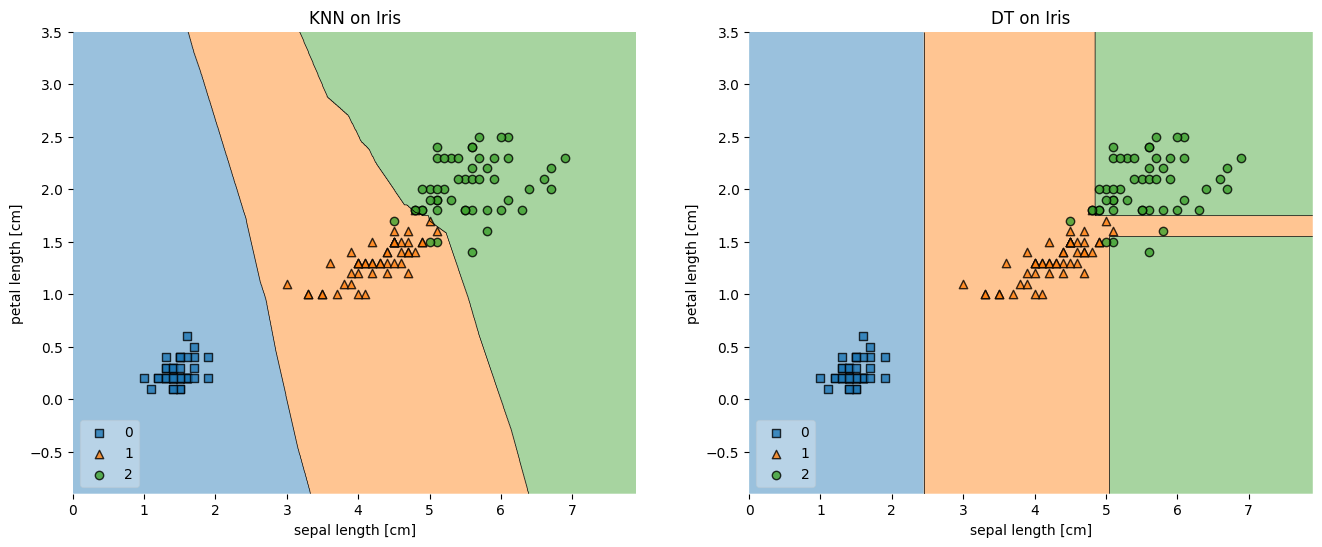

In [8]:
# Plotting decision regions
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))

plot_decision_regions(X, y, clf=knn, legend=3, ax=ax1)

# Adding axes annotations
ax1.set_xlabel('sepal length [cm]')
ax1.set_ylabel('petal length [cm]')
ax1.set_title('KNN on Iris')

plot_decision_regions(X, y, clf=dt, legend=3, ax=ax2)

# Adding axes annotations
ax2.set_xlabel('sepal length [cm]')
ax2.set_ylabel('petal length [cm]')
ax2.set_title('DT on Iris')

#### Highlight test points

In [11]:
from mlxtend.preprocessing import shuffle_arrays_unison

In [12]:
# Loading some example data
iris = datasets.load_iris()
X, y = iris.data[:, [0,2]], iris.target
X, y = shuffle_arrays_unison(arrays=[X, y], random_seed=3)

X_train, y_train = X[:100], y[:100]
X_test, y_test   = X[100:], y[100:]

In [13]:
# Training a classifier
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)

KNeighborsClassifier()

D:\Anaconda-16-FEB\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)


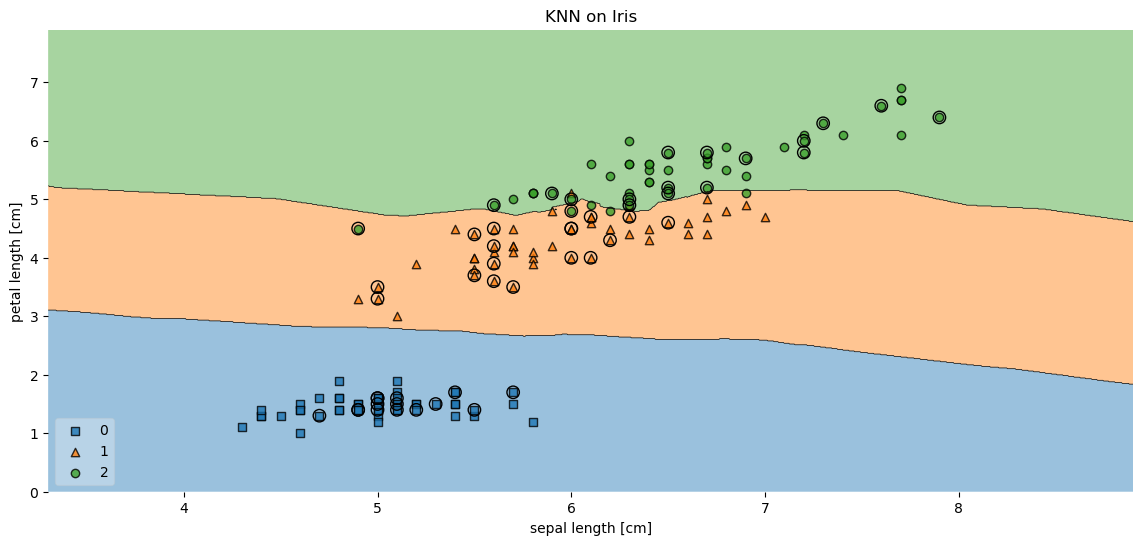

In [14]:
# Plotting decision regions
plt.figure(figsize=(14, 6))

# Plotting decision regions
plot_decision_regions(X, y, 
                      clf        = model, 
                      legend     = 3, 
                      X_highlight= X_test)

# Adding axes annotations
plt.xlabel('sepal length [cm]')
plt.ylabel('petal length [cm]')
plt.title('KNN on Iris');

#### some random test samples

#### All columns together
-taking a pair of columns, at a time

In [15]:
import numpy as np
from itertools import combinations

In [16]:
iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [17]:
number_of_columns     = len(iris.feature_names)
total_number_of_plots = len(list(combinations(range(number_of_columns), 2)))

number_of_columns, total_number_of_plots

(4, 6)

D:\Anaconda-16-FEB\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)
D:\Anaconda-16-FEB\lib\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True o

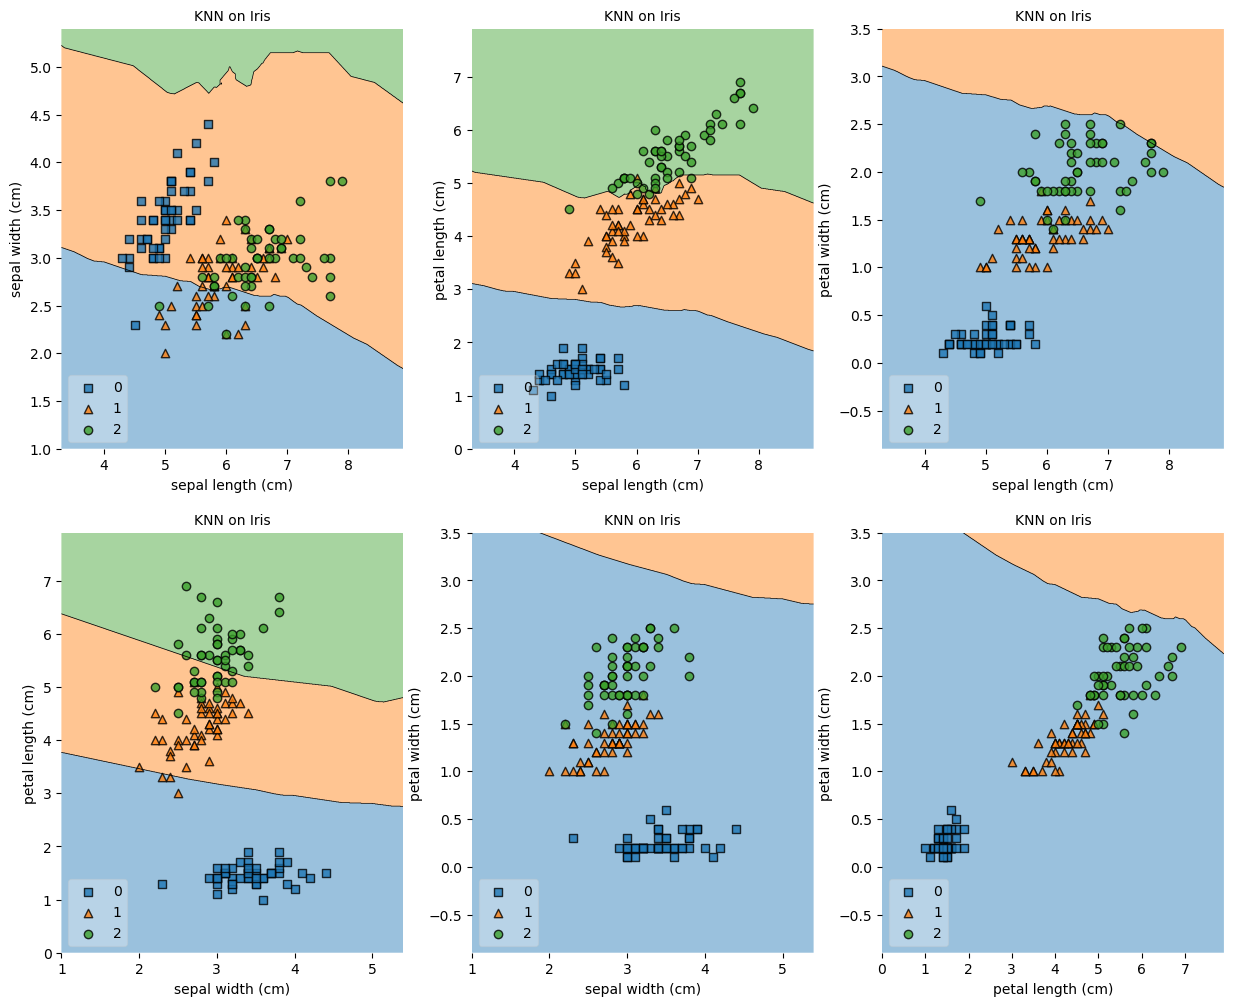

In [18]:
# Subplots are organized in a Rows x Cols Grid
number_plots_per_row = 3

# Compute Rows required
numer_plot_rows  = total_number_of_plots // number_plots_per_row 
numer_plot_rows += total_number_of_plots % number_plots_per_row

# Create a plot position index
plot_position = range(1, total_number_of_plots + 1)

# Create main figure
fig = plt.figure(figsize=(number_plots_per_row*5, numer_plot_rows* 6))

k = 0
for col1, col2 in list(combinations(range(number_of_columns), 2)):

    # add every single subplot to the figure with a for loop
    ax = fig.add_subplot(numer_plot_rows, number_plots_per_row, plot_position[k])
    k += 1
    
    X, y = iris.data[:, [col1, col2]], iris.target
    X, y = shuffle_arrays_unison(arrays=[X, y], random_seed=3)
    
    plot_decision_regions(X, 
                          y, 
                          clf=model, 
                          legend=3)

    # Adding axes annotations
    plt.xlabel(iris.feature_names[col1], fontsize=10)
    plt.ylabel(iris.feature_names[col2], fontsize=10)
    plt.title('KNN on Iris', fontsize=10);

#### demo on non linear

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB 
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn import datasets
import numpy as np

In [10]:
# # Initializing Classifiers
clf1 = LogisticRegression(random_state=1,
                          solver='newton-cg',
                          multi_class='multinomial')
clf2 = RandomForestClassifier(random_state=1, n_estimators=100)
clf3 = GaussianNB()
clf4 = SVC(gamma='auto', kernel='linear')

D:\python_envs\genai_gpt_lc_vdb_trnsf\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


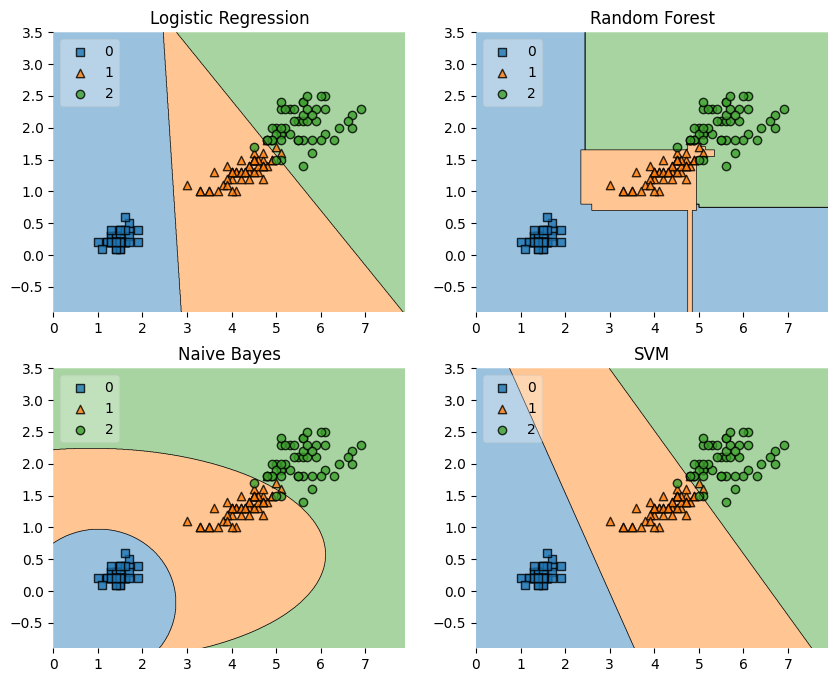

In [11]:
import matplotlib.pyplot as plt
from mlxtend.plotting import plot_decision_regions
import matplotlib.gridspec as gridspec
import itertools
gs = gridspec.GridSpec(2, 2)

fig = plt.figure(figsize=(10,8))

labels = ['Logistic Regression', 'Random Forest', 'Naive Bayes', 'SVM']
for clf, lab, grd in zip([clf1, clf2, clf3, clf4],
                         labels,
                         itertools.product([0, 1], repeat=2)):

    clf.fit(X, y)
    ax = plt.subplot(gs[grd[0], grd[1]])
    fig = plot_decision_regions(X=X, y=y, clf=clf, legend=2)
    plt.title(lab)
